# Bivariate Analysis: What Drives Churn?
In this notebook, we move from looking at individual variables to understanding the **relationship** between our features and our target variable: `Churn`. 

We want to answer key business questions like:
*   Does the type of contract affect churn?
*   Are certain internet services more prone to churn?
*   Do higher monthly charges correlate with leaving?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load and repeat the cleaning from Notebook 02
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Helper function to plot categorical churn rates
def plot_churn_rate(feature, df):
    plt.figure(figsize=(10, 5))
    # Calculate churn rate per category
    churn_rate = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack()
    churn_rate.plot(kind='bar', stacked=True, color=['#A8E6CF', '#FF8B94'], figsize=(10, 6))
    plt.title(f'Churn Rate by {feature}')
    plt.ylabel('Proportion')
    plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

print("Setup complete. Data cleaned and helper functions ready.")

Setup complete. Data cleaned and helper functions ready.


## 1. Contracts & Churn
**Question:** Do customers on Month-to-Month contracts churn more?
Let's look at the churn rate across different contract types (`Month-to-month`, `One year`, `Two year`).

<Figure size 1000x500 with 0 Axes>

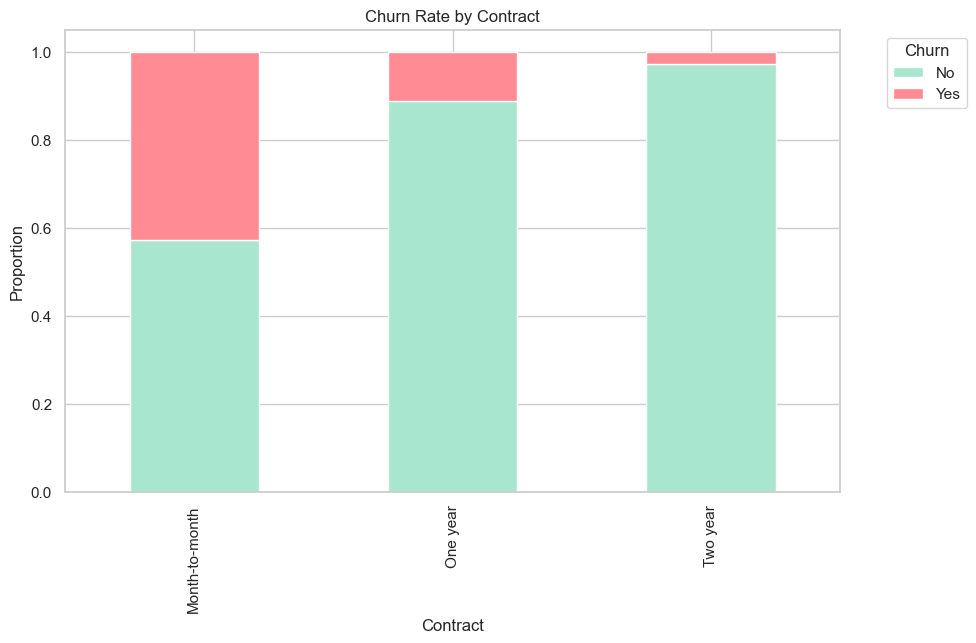

In [2]:
plot_churn_rate('Contract', df)

**Observations (Contract Type):**
> We can see that customers with month to month are most likely to churn. Followed by customers with one year contracts, and finally those with two year contracts are least likely to churn.

## 2. Internet Services & Churn
**Question:** Does Fiber Optic internet have a higher churn rate?
Compare `DSL`, `Fiber optic`, and `No internet service`.

<Figure size 1000x500 with 0 Axes>

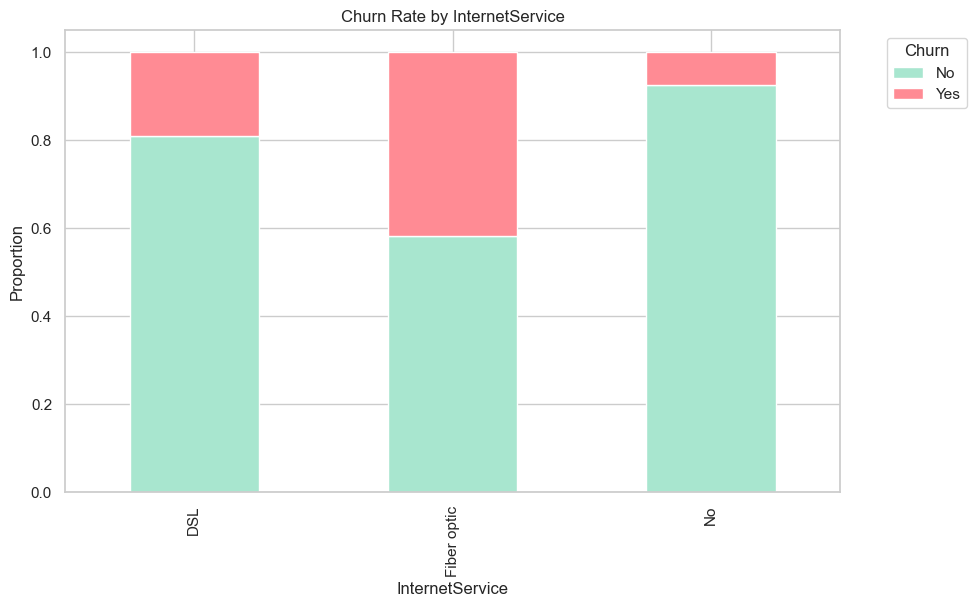

In [4]:
plot_churn_rate('InternetService', df)

**Observations (Internet Service):**
> While Fiber Optic is a premium service, customers using it churn at a higher rate than those on DSL or those with no internet service at all. This is a huge red flag for the business—perhaps the priced-to-performance ratio for Fiber isn't satisfying customers, or they are experiencing more technical issues.

## 3. Demographics & Churn
**Questions:** Does being a Senior Citizen or having a Partner/Dependents impact churn?

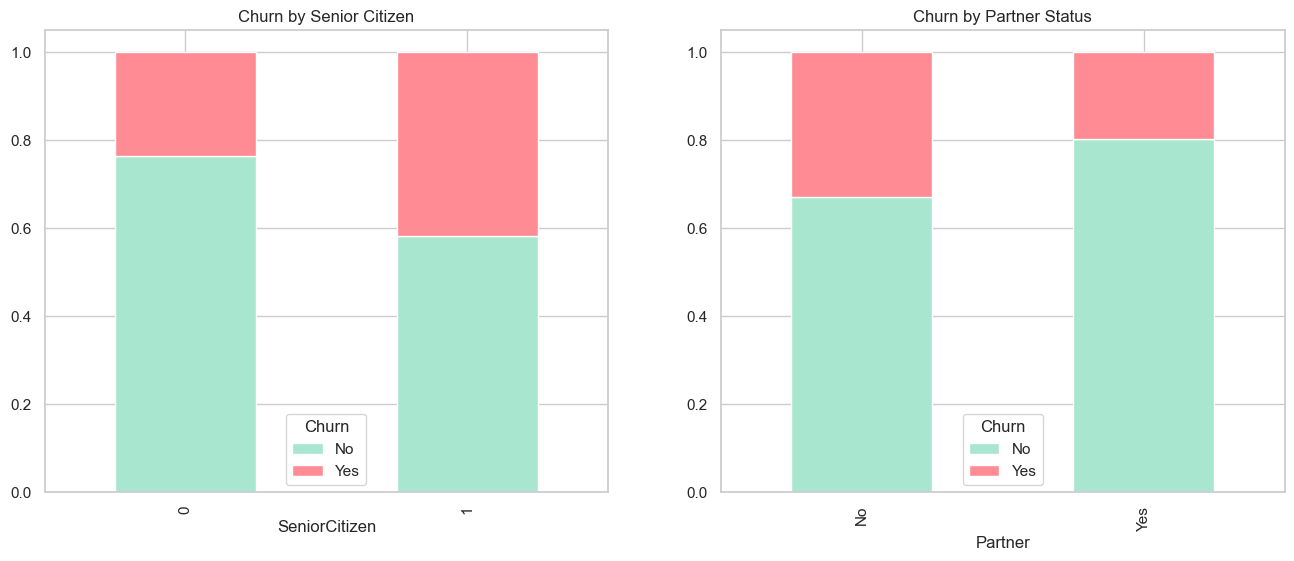

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()
senior_churn.plot(kind='bar', stacked=True, ax=axes[0], color=['#A8E6CF', '#FF8B94'])
axes[0].set_title('Churn by Senior Citizen')

# Partner
partner_churn = df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack()
partner_churn.plot(kind='bar', stacked=True, ax=axes[1], color=['#A8E6CF', '#FF8B94'])
axes[1].set_title('Churn by Partner Status')

plt.show()

**Observations (Demographics):**
> The Data:
Senior Citizens churn at a much higher rate than non-seniors.
Customers with Partners or Dependents tend to stay longer (lower churn). They are likely "household" accounts which are more "sticky" and harder to move than accounts for individuals.

## 4. Numeric Features vs Churn
**Question:** How do `tenure` and `MonthlyCharges` relate to a customer's decision to leave?

/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19868/4017723880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2')
/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19868/4017723880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2')


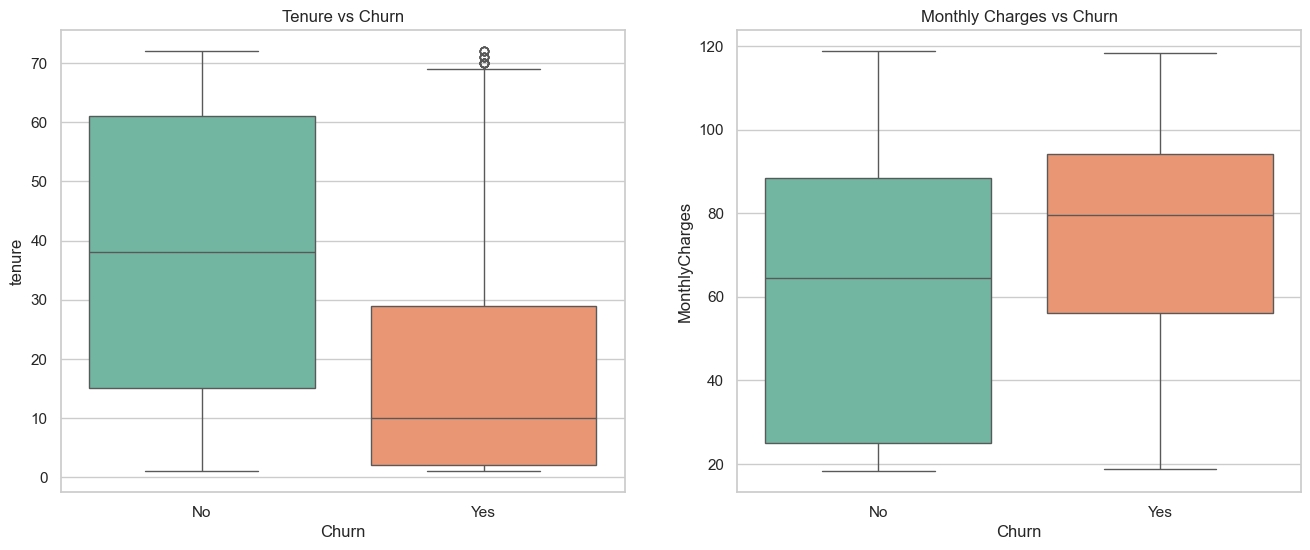

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges vs Churn')

plt.show()

**Observations (Numeric Impact):**
> *Look at the medians (the horizontal lines in the boxes). Are customers who churn usually 'newer' (lower tenure)? Do they pay more per month on average?*